# FlyWire connectome analysis tutorial

This notebook provides a comprehensive tutorial for analyzing the [FlyWire](https://codex.flywire.ai/) connectome using the available CSV tables. We'll explore neuron properties, connectivity patterns, and neurotransmitter distributions. We'll start by importing a few modules, and configuring the notebook to display figures inline:

In [ ]:
%matplotlib inline

import re
from collections import Counter, defaultdict
from gzip import decompress
from pathlib import Path
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch
from mpl_toolkits.mplot3d.art3d import Line3DCollection

Now, let's download files from the [Female Adult Fly Brain](https://codex.flywire.ai/?dataset=fafb) (FAFB) dataset, if we don't have them already:

In [ ]:
def _download_fafb_dataset_if_missing() -> None:
    url_template = (
        "https://storage.googleapis.com/flywire-data/codex/data/fafb/783/%s.csv.gz"
    )
    table_names = [
        "neurons",
        "connections_princeton",
        "classification",
        "coordinates",
    ]

    if Path("_inbox/fafb").is_dir():
        return

    for table_name in table_names:
        print(f"Downloading `{table_name}.csv`...")
        stream = urlopen(url_template % table_name)
        output_path = Path(f"_inbox/fafb/{table_name}.csv")
        output_path.parent.mkdir(parents=True, exist_ok=True)
        output_path.write_bytes(decompress(stream.read()))

_download_fafb_dataset_if_missing()

And load the data into memory as [Pandas dataframes](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.html) (tables):

In [ ]:
neuron_table = pd.read_csv("_inbox/fafb/neurons.csv")
connection_table = pd.read_csv("_inbox/fafb/connections_princeton.csv")
classification_table = pd.read_csv("_inbox/fafb/classification.csv")
coordinate_table = pd.read_csv("_inbox/fafb/coordinates.csv")

## Dataset overview

Let's take a look at what these tables contain. The `neurons.csv` table has one row per neuron, and each row has the following fields:

- `root_id`: A number identifying the neuron (potentially the ID of a "root segment" that other segments were merged into during tracing)
- `group`: The group name assigned to the neuron based on its primary input and output neuropils
- `nt_type`: The predicted neurotransmitter type
- `nt_type_score`: The average probability the neurotransmitter-type classifier assigned to the neuron"s synapses, for the predicted neurotransmitter type
- `da_avg`: The average probability the classifier assigned to the neuron"s synapses for dopamine
- `ser_avg`: The average probability the classifier assigned to the neuron"s synapses for serotonin
- `gaba_avg`: The average probability the classifier assigned to the neuron"s synapses for GABA
- `glut_avg`: The average probability the classifier assigned to the neuron"s synapses for glutamate
- `ach_avg`: The average probability the classifier assigned to the neuron"s synapses for acetylcholine
- `oct_avg`: The average probability the classifier assigned to the neuron"s synapses for octopamine

In [4]:
print(f"`neurons.csv` ({neuron_table.shape[0]:,} rows):\n")
print(neuron_table.head().to_string(line_width=120))

`neurons.csv` (139,255 rows):

              root_id   group nt_type  nt_type_score  da_avg  ser_avg  gaba_avg  glut_avg  ach_avg  oct_avg
0  720575940596125868  LO.LOP     ACH           0.57    0.03     0.00      0.05      0.28     0.57     0.07
1  720575940597856265      ME     ACH           0.85    0.01     0.00      0.03      0.04     0.85     0.07
2  720575940597944841   ME.LO     ACH           0.82    0.02     0.00      0.01      0.05     0.82     0.09
3  720575940598267657      ME    GABA           0.74    0.01     0.01      0.74      0.19     0.03     0.02
4  720575940599333574      ME     ACH           0.61    0.02     0.00      0.13      0.13     0.61     0.11


The `connections_princeton.csv` table has one row per (input neuron, output neuron, connecting neuropil) triple, and each row has the following fields:

- `pre_root_id`: The presynaptic neuron identifier
- `post_root_id`: The postsynaptic neuron identifier
- `neuropil`: The identifier of a neuropil connecting the presynaptic and postsynaptic neurons
- `syn_count`: The number of synapses connecting the two neurons in that neuropil (which may not be the total number of neurons connecting those two neurons, if other connections between them exist)
- `nt_type`: The predicted neurotransmitter type

It's called `connections_princeton.csv` because it was post-processed by researchers at Princeton University. (See the FAFB download page for details.) An unprocessed connection table is also available, but we won't be using it in our analysis.

In [5]:
print(f"`connections_princeton.csv` ({connection_table.shape[0]:,} rows):\n")
print(connection_table.head().to_string(line_width=120))

`connections_princeton.csv` (5,342,446 rows):

          pre_root_id        post_root_id neuropil  syn_count nt_type
0  720575940625363947  720575940623224444     ME_L         12    GABA
1  720575940630432382  720575940618518557     ME_L         67     ACH
2  720575940627314521  720575940626337738     ME_L         10    GABA
3  720575940620280405  720575940620204726     ME_L         15     ACH
4  720575940636942447  720575940613789411     LA_L          1    GLUT


The `classification.csv` table has one row per neuron, and each row has the following fields:

- `root_id`: A number identifying the neuron
- `flow`: A top-level hierarchical annotation, which describes the signal flow of the neuron
- `super_class`: The hierarchical annotation below `flow`
- `class`: The hierarchical annotation below `super_class`, or `NaN`, if the neuron isn't labeled at this level
- `sub_class`: The hierarchical annotation below `class`, or `NaN`, if the neuron isn't labeled at this level
- `hemilineage`: The developmental (hemi-)lineage the neuron belongs to, or `NaN`, if the neuron isn't labeled at this level
- `side`: The soma side of the neuron in fly"s perspective
- `nerve`: The nerve through which the neuron is entering or exiting the nervous system, or `NaN`, if the neuron is intrinsic or the nerve annotation is missing

In [6]:
print(f"`classification.csv` ({classification_table.shape[0]:,} rows):\n")
print(classification_table.head().to_string(line_width=120))

`classification.csv` (139,255 rows):

              root_id       flow super_class                 class         sub_class hemilineage   side nerve
0  720575940596125868  intrinsic       optic  optic_lobe_intrinsic         t5_neuron         NaN  right   NaN
1  720575940597856265  intrinsic       optic  optic_lobe_intrinsic    transmedullary         NaN  right   NaN
2  720575940597944841  intrinsic       optic  optic_lobe_intrinsic    transmedullary         NaN  right   NaN
3  720575940598267657  intrinsic       optic  optic_lobe_intrinsic  transmedullary_y         NaN  right   NaN
4  720575940599333574  intrinsic       optic  optic_lobe_intrinsic    transmedullary         NaN  right   NaN


The final table we'll load is the `coordinates.csv` table, which describes spatial markers placed on neurons during the annotation process. It has one row per marker (neurons can have muliple markers), and each row has the following fields:

- `root_id`: A number identifying the neuron
- `position`: The (_x_, _y_, _z_) position of the marker; the coordinates usually point to spots that were most useful for human review, and not necessarily to the soma
- `supervoxel_id`: The supervoxel ID associated with the position (which is potentially useful for spatial indexing)

In [7]:
print(f"`coordinates.csv` ({coordinate_table.shape[0]:,} rows):\n")
print(coordinate_table.head().to_string(line_width=120))

`coordinates.csv` (238,909 rows):

              root_id                position      supervoxel_id
0  720575940613726179  [352484 175164 229040]  76704474512672967
1  720575940623219453  [631424 216180  55880]  81490235707935665
2  720575940613998790  [713412 223496  57080]  82897679310436225
3  720575940606611401  [444928 283372  77240]  78254373054459056
4  720575940620628957  [516764 103356  67880]  79517986792372064


## Inspecting groups of neurons

Let's print the number of cells in various combinations of cell classes/subclasses. Note that that classes aren't arranged in a strict taxonomy.

In [8]:
def _print_per_group_cell_counts() -> None:
    path_part_names = ["flow", "super_class", "class", "sub_class"]
    counters = [Counter[str]() for _ in range(len(path_part_names) + 1)]

    for row in classification_table.to_records():
        stringify = lambda entry: entry if isinstance(entry, str) else "<no_label>"
        path_parts = tuple(stringify(row[name]) for name in path_part_names)
        for i, counter in enumerate(counters):
            counter["/".join(path_parts[:i])] += 1

    print(f"Total cell count: {counters[0]['']:,}")

    for path_part_name, counter in zip(path_part_names, counters[1:]):
        print(f"\nCell counts by {path_part_name.replace('_', '')}:")
        for path, count in sorted(counter.items()):
            print(f"- {path}: {count:,} cell{'s' if count > 1 else ''}")

_print_per_group_cell_counts()

Total cell count: 139,255

Cell counts by flow:
- afferent: 19,265 cells
- efferent: 1,489 cells
- intrinsic: 118,501 cells

Cell counts by superclass:
- afferent/ascending: 2,362 cells
- afferent/optic: 75 cells
- afferent/sensory: 16,828 cells
- efferent/descending: 1,303 cells
- efferent/endocrine: 80 cells
- efferent/motor: 106 cells
- intrinsic/central: 32,388 cells
- intrinsic/optic: 77,774 cells
- intrinsic/sensory: 153 cells
- intrinsic/visual_centrifugal: 521 cells
- intrinsic/visual_projection: 7,665 cells

Cell counts by class:
- afferent/ascending/AN: 2,362 cells
- afferent/optic/optic_lobe_intrinsic: 75 cells
- afferent/sensory/<no_label>: 2 cells
- afferent/sensory/gustatory: 343 cells
- afferent/sensory/hygrosensory: 74 cells
- afferent/sensory/mechanosensory: 2,648 cells
- afferent/sensory/olfactory: 2,281 cells
- afferent/sensory/thermosensory: 29 cells
- afferent/sensory/unknown_sensory: 135 cells
- afferent/sensory/visual: 11,316 cells
- efferent/descending/<no_label

And now let's visualize groups of neurons within the same superclass (the second-highest level of the group scale hierarchy) to get a sense of where they are in the brain:

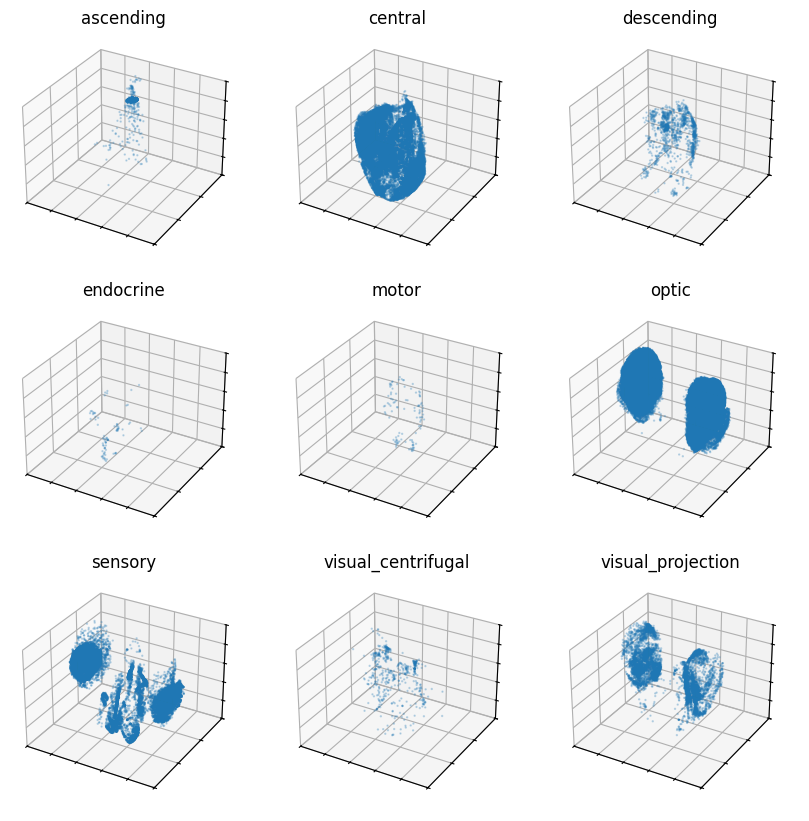

In [9]:
def _vis_cell_groups() -> None:
    superclass_labels = {
        entry["root_id"]: str(entry["super_class"])
        for entry in classification_table.to_records()
    }

    figure = plt.figure(figsize=(10, 10))

    for i, superclass in enumerate(sorted(set(superclass_labels.values()))):
        locs = list[list[float]]()
        for root_id, subtable in coordinate_table.groupby("root_id"):
            if superclass_labels[root_id] == superclass:
                coord_strings = re.findall(r"\d+", subtable.iloc[0]["position"])
                loc = list(map(float, coord_strings))
                locs.append(loc)

        subplot = figure.add_subplot(3, 3, i + 1, projection="3d")
        subplot.set_title(superclass)
        subplot.scatter(*np.array(locs).T, s=0.5, alpha=0.25)
        subplot.axes.set_xlim(0, 1_000_000)  # type: ignore
        subplot.axes.set_ylim(0, 600_000)  # type: ignore
        subplot.axes.set_zlim(0, 250_000)  # type: ignore
        subplot.axes.set_xticklabels([])  # type: ignore
        subplot.axes.set_yticklabels([])  # type: ignore
        subplot.axes.set_zticklabels([])  # type: ignore

    plt.show()

_vis_cell_groups()


## Visualizing group-level connectivity

Now that we have a sense of which populations of neurons are represented in the dataset, let's try to understand how they're connected, at a coarse level. We'll start by generating a cell-class-level connectivity matrices:

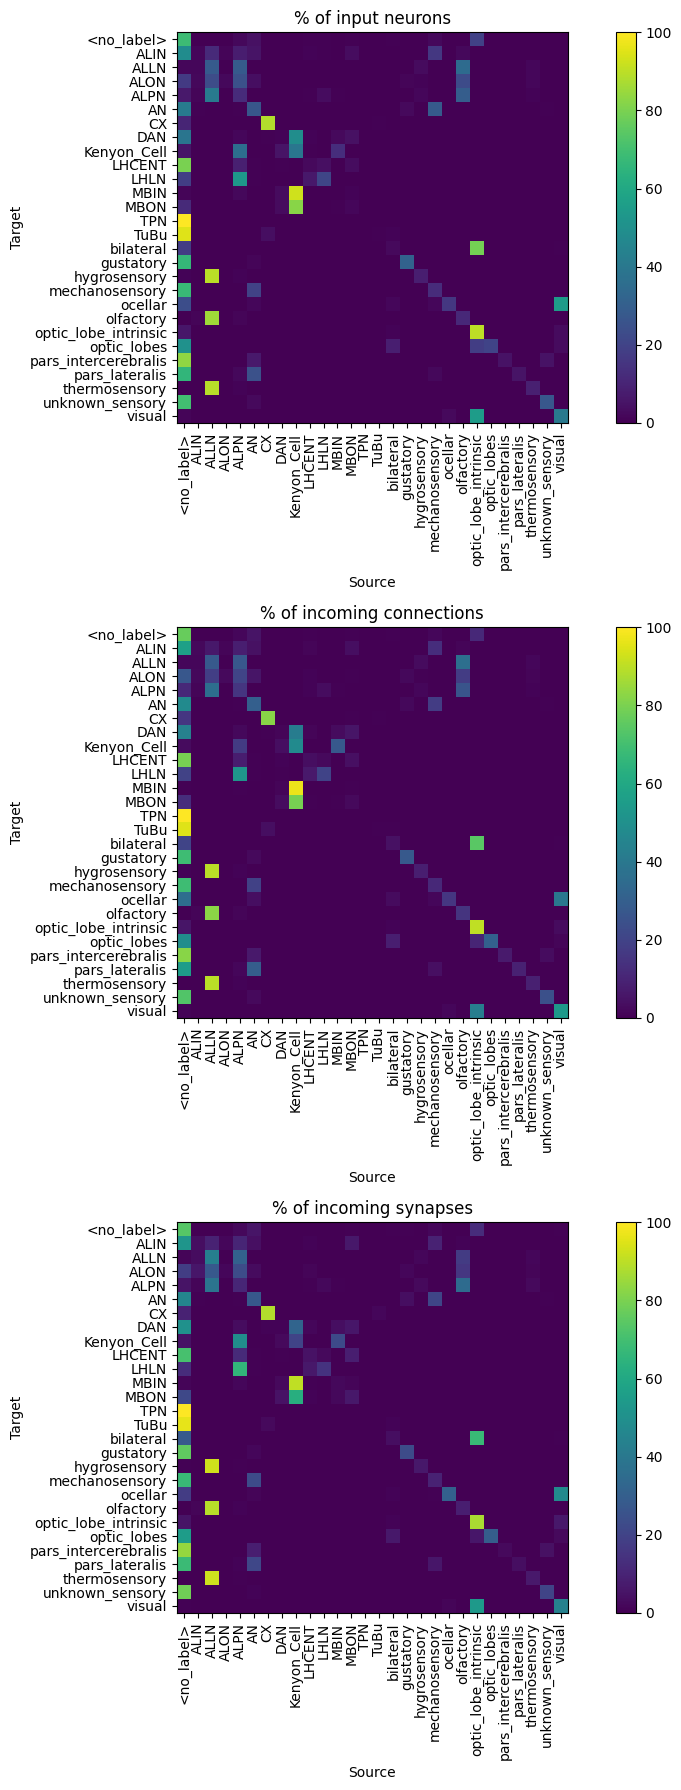

In [10]:
def _show_connectivity_matrices() -> None:
    stringify = lambda c: c if isinstance(c, str) else "<no_label>"
    class_labels = {
        entry["root_id"]: stringify(entry["class"])
        for entry in classification_table.to_records()
    }
    class_indices = {
        label: i for i, label in enumerate(sorted(set(class_labels.values())))
    }

    n_classes = len(set(class_labels.values()))
    input_neur_counts = np.zeros((n_classes, n_classes))
    input_conn_counts = np.zeros((n_classes, n_classes))
    input_syn_counts = np.zeros((n_classes, n_classes))

    for root_ids, _ in connection_table.groupby(["pre_root_id", "post_root_id"]):
        pre_sc_index = class_indices[class_labels[root_ids[0]]]
        post_sc_index = class_indices[class_labels[root_ids[1]]]
        input_neur_counts[post_sc_index, pre_sc_index] += 1

    for conn in connection_table.to_records():
        pre_sc_index = class_indices[class_labels[conn["pre_root_id"]]]
        post_sc_index = class_indices[class_labels[conn["post_root_id"]]]
        input_conn_counts[post_sc_index, pre_sc_index] += 1
        input_syn_counts[post_sc_index, pre_sc_index] += conn["syn_count"]

    input_neur_fracs = input_neur_counts / input_neur_counts.sum(axis=1, keepdims=True)
    input_conn_fracs = input_conn_counts / input_conn_counts.sum(axis=1, keepdims=True)
    input_syn_fracs = input_syn_counts / input_syn_counts.sum(axis=1, keepdims=True)

    figure = plt.figure(figsize=(10, 18))

    sb = figure.add_subplot(3, 1, 1)
    sb.set_title(r"% of input neurons")
    graphic = sb.matshow(100.0 * input_neur_fracs)
    figure.colorbar(graphic)
    sb.axes.xaxis.set_ticks_position("bottom")  # type: ignore
    sb.set_xlabel("Source")
    sb.set_ylabel("Target")
    sb.set_xticks(
        np.arange(len(class_indices)),
        class_indices.keys(),
        rotation=90,
    )
    sb.set_yticks(
        np.arange(len(class_indices)),
        class_indices.keys(),
    )

    sb = figure.add_subplot(3, 1, 2)
    sb.set_title(r"% of incoming connections")
    graphic = sb.matshow(100.0 * input_conn_fracs)
    figure.colorbar(graphic)
    sb.axes.xaxis.set_ticks_position("bottom")  # type: ignore
    sb.set_xlabel("Source")
    sb.set_ylabel("Target")
    sb.set_xticks(
        np.arange(len(class_indices)),
        class_indices.keys(),
        rotation=90,
    )
    sb.set_yticks(
        np.arange(len(class_indices)),
        class_indices.keys(),
    )

    sb = figure.add_subplot(3, 1, 3)
    sb.set_title(r"% of incoming synapses")
    graphic = sb.matshow(100.0 * input_syn_fracs)
    figure.colorbar(graphic)
    sb.axes.xaxis.set_ticks_position("bottom")  # type: ignore
    sb.set_xlabel("Source")
    sb.set_ylabel("Target")
    sb.set_xticks(
        np.arange(len(class_indices)),
        class_indices.keys(),
        rotation=90,
    )
    sb.set_yticks(
        np.arange(len(class_indices)),
        class_indices.keys(),
    )

    figure.tight_layout()
    plt.show()

_show_connectivity_matrices()


Next, let's visualize one of these connection groups (corresponding to a single entry in each of the above matrices) spatially:

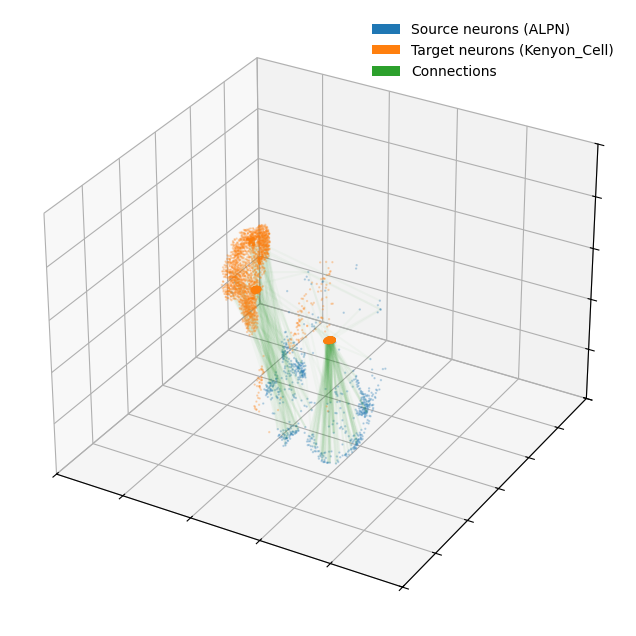

In [11]:
def _vis_connection_group() -> None:
    source_class = "ALPN"
    target_class = "Kenyon_Cell"
    n_conn = 300

    class_labels = {
        entry["root_id"]: str(entry["class"])
        for entry in classification_table.to_records()
    }

    source_locs = dict[int, list[float]]()
    for root_id, subtable in coordinate_table.groupby("root_id"):
        if class_labels[root_id] == source_class:
            coord_strings = re.findall(r"\d+", subtable.iloc[0]["position"])
            source_locs[root_id] = list(map(float, coord_strings))  # type: ignore

    target_locs = dict[int, list[float]]()
    for root_id, subtable in coordinate_table.groupby("root_id"):
        if class_labels[root_id] == target_class:
            coord_strings = re.findall(r"\d+", subtable.iloc[0]["position"])
            target_locs[root_id] = list(map(float, coord_strings))  # type: ignore

    conn_source_locs = list[list[float]]()
    conn_target_locs = list[list[float]]()
    for connection in connection_table.to_records():
        pre_id = connection["pre_root_id"]
        post_id = connection["post_root_id"]
        if pre_id in source_locs and post_id in target_locs:
            conn_source_locs.append(source_locs[pre_id])
            conn_target_locs.append(target_locs[post_id])

    conn_indices = np.random.choice(len(conn_source_locs), n_conn)
    selected_source_locs = np.take(conn_source_locs, conn_indices, axis=0)
    selected_target_locs = np.take(conn_target_locs, conn_indices, axis=0)

    figure = plt.figure(figsize=(8, 8))
    subplot = figure.add_subplot(projection="3d")
    subplot.scatter(
        *np.array(list(source_locs.values())).T,
        s=0.5,
        color="C0",
        alpha=0.25,
    )
    subplot.scatter(
        *np.array(list(target_locs.values())).T,
        s=0.5,
        color="C1",
        alpha=0.25,
    )
    subplot.axes.add_collection3d(  # type: ignore
        Line3DCollection(
            np.stack([selected_source_locs, selected_target_locs], axis=1),
            alpha=0.03,
            color="C2",
        ),
    )
    subplot.legend(
        labels=[
            f"Source neurons ({source_class})",
            f"Target neurons ({target_class})",
            "Connections",
        ],
        handles=[
            Patch(facecolor="C0"),
            Patch(facecolor="C1"),
            Patch(facecolor="C2"),
        ],
        frameon=False,
    )
    subplot.axes.set_xlim(0, 1_000_000)  # type: ignore
    subplot.axes.set_ylim(0, 600_000)  # type: ignore
    subplot.axes.set_zlim(0, 250_000)  # type: ignore
    subplot.axes.set_xticklabels([])  # type: ignore
    subplot.axes.set_yticklabels([])  # type: ignore
    subplot.axes.set_zticklabels([])  # type: ignore

    plt.show()

_vis_connection_group()

## Neurotransmitter statistics

Next, let's take a look a the distribution of neurotransmitter expression across the neurons in the dataset:

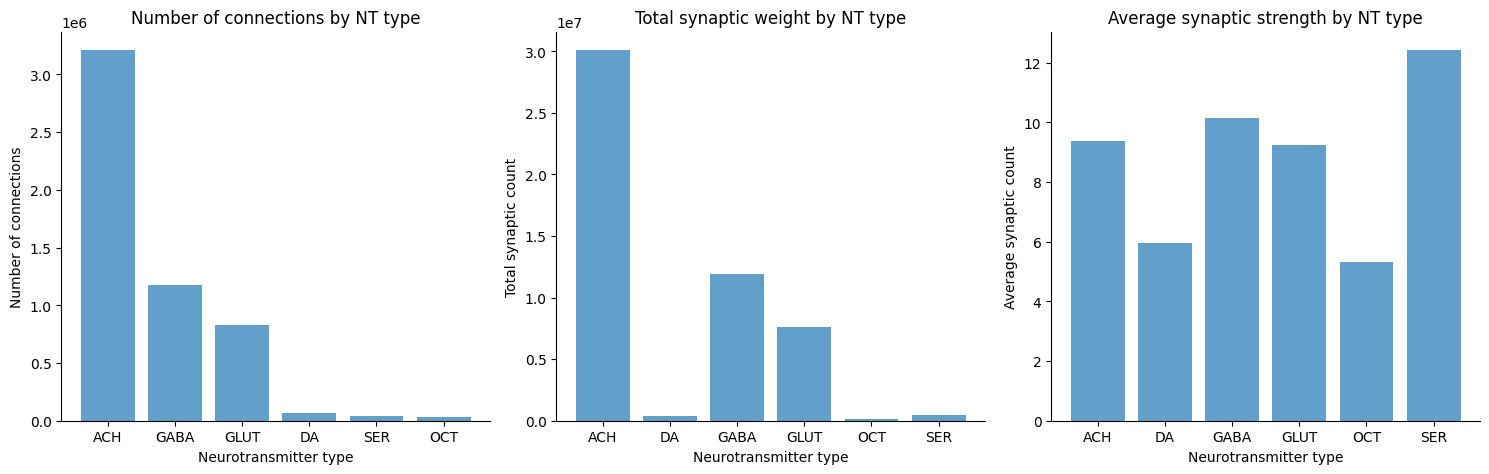

In [12]:
def _vis_nt_type_distribution() -> None:
    _, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Number of connections by NT type
    nt_counts = connection_table["nt_type"].value_counts()
    axes[0].bar(nt_counts.index, nt_counts.values, alpha=0.7)
    axes[0].set_title("Number of connections by NT type")
    axes[0].set_xlabel("Neurotransmitter type")
    axes[0].set_ylabel("Number of connections")
    axes[0].spines[["top", "right"]].set_visible(False)

    # Total synaptic weight by NT type
    nt_weights = connection_table.groupby("nt_type")["syn_count"].sum()
    axes[1].bar(nt_weights.index, nt_weights.values, alpha=0.7)
    axes[1].set_title("Total synaptic weight by NT type")
    axes[1].set_xlabel("Neurotransmitter type")
    axes[1].set_ylabel("Total synaptic count")
    axes[1].spines[["top", "right"]].set_visible(False)

    # Average synaptic strength by NT type
    nt_avg_strength = connection_table.groupby("nt_type")["syn_count"].mean()
    axes[2].bar(nt_avg_strength.index, nt_avg_strength.values, alpha=0.7)
    axes[2].set_title("Average synaptic strength by NT type")
    axes[2].set_xlabel("Neurotransmitter type")
    axes[2].set_ylabel("Average synaptic count")
    axes[2].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

_vis_nt_type_distribution()

We can also break things down by cell superclass:

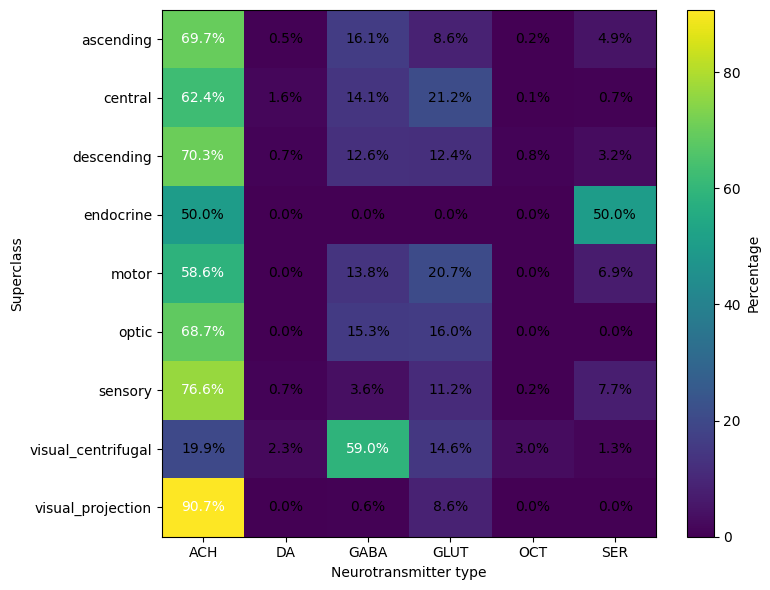

In [ ]:
def _vis_per_class_nt_type_distributions() -> None:
    joint_table = pd.merge(neuron_table, classification_table, on="root_id", how="left")
    nt_by_class = joint_table.groupby(["super_class", "nt_type"]).size().unstack(fill_value=0)

    _, ax = plt.subplots(figsize=(8, 6))
    nt_by_class_pct = nt_by_class.div(nt_by_class.sum(axis=1), axis=0) * 100
    im = ax.imshow(nt_by_class_pct.values, cmap="viridis", aspect="auto")

    ax.set_xlabel("Neurotransmitter type")
    ax.set_ylabel("Superclass")
    ax.set_xticks(range(len(nt_by_class_pct.columns)))
    ax.set_xticklabels(nt_by_class_pct.columns)
    ax.set_yticks(range(len(nt_by_class_pct.index)))
    ax.set_yticklabels(nt_by_class_pct.index)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Percentage")

    for i in range(len(nt_by_class_pct.index)):
        for j in range(len(nt_by_class_pct.columns)):
            ax.text(
                *(j, i, f"{nt_by_class_pct.iloc[i, j]:.1f}%"),
                ha="center",
                va="center",
                color=("white" if nt_by_class_pct.iloc[i, j] > 50 else "black"),  # type: ignore
            )

    plt.tight_layout()
    plt.show()

_vis_per_class_nt_type_distributions()

**Suggested exercise:** Construct and display a connection matrix that shows how often neurons expressing a given neurotransmitter NT1 connect to neurons expressing another neurotransmitter NT2.

In [14]:
### Your code here ###

## Analyzing cell-to-cell connectivity

Let's now transition to a finer scale of analysis. We'll start by plotting the distributions of synapse counts associated with individual connections:

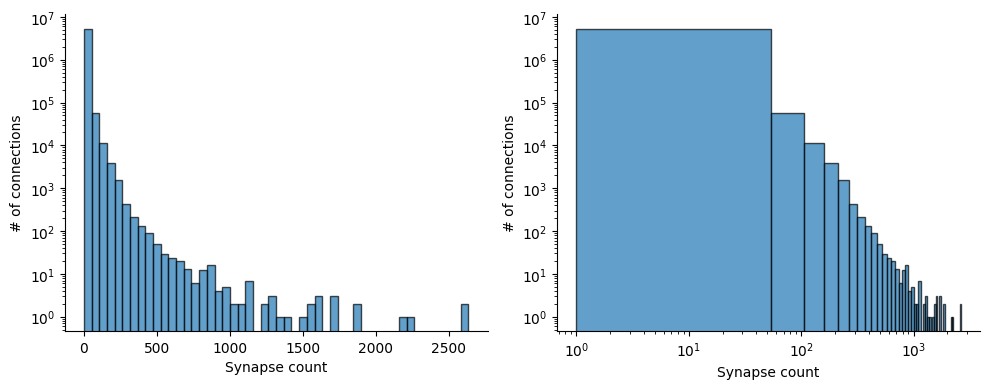

In [15]:
def _vis_connectivity_distribution() -> None:
    _, axes = plt.subplots(1, 2, figsize=(10, 4))

    # Linear-scale histogram
    axes[0].hist(connection_table["syn_count"], bins=50, alpha=0.7, edgecolor="black")
    axes[0].set_xlabel("Synapse count")
    axes[0].set_ylabel("# of connections")
    axes[0].set_yscale("log")
    axes[0].spines[["top", "right"]].set_visible(False)

    # Log-scale histogram
    axes[1].hist(connection_table["syn_count"], bins=50, alpha=0.7, edgecolor="black")
    axes[1].set_xlabel("Synapse count") 
    axes[1].set_ylabel("# of connections")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

_vis_connectivity_distribution()

Next, let's compute in-degree (input count) and out-degree (output count) distributions for the dataset:

In [ ]:
def _get_connection_stats() -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    pre_ids = connection_table["pre_root_id"]
    post_ids = connection_table["post_root_id"]
    neuron_ids = set(pre_ids.unique()) | set(post_ids.unique())

    in_degree = defaultdict[int, int](int)
    out_degree = defaultdict[int, int](int)
    weighted_in_degree = defaultdict[int, int](int)
    weighted_out_degree = defaultdict[int, int](int)

    for _, row in connection_table.iterrows():
        pre_id = row["pre_root_id"]
        post_id = row["post_root_id"]
        syn_count = row["syn_count"]

        out_degree[pre_id] += 1
        in_degree[post_id] += 1
        weighted_out_degree[pre_id] += syn_count
        weighted_in_degree[post_id] += syn_count

    in_degrees = np.array([in_degree[nid] for nid in neuron_ids])
    out_degrees = np.array([out_degree[nid] for nid in neuron_ids])
    weighted_in_degrees = np.array([weighted_in_degree[nid] for nid in neuron_ids])
    weighted_out_degrees = np.array([weighted_out_degree[nid] for nid in neuron_ids])
    return in_degrees, out_degrees, weighted_in_degrees, weighted_out_degrees

in_degrees, out_degrees, weighted_in_degrees, weighted_out_degrees = _get_connection_stats()

print(f"Average in-degree: {np.mean(in_degrees):.2f}")
print(f"Average out-degree: {np.mean(out_degrees):.2f}")
print(f"Average weighted in-degree: {np.mean(weighted_in_degrees):.2f}")
print(f"Average weighted out-degree: {np.mean(weighted_out_degrees):.2f}")


Average in-degree: 38.55
Average out-degree: 38.55
Average weighted in-degree: 365.60
Average weighted out-degree: 365.60


Now let's visualize these distributions as histograms:

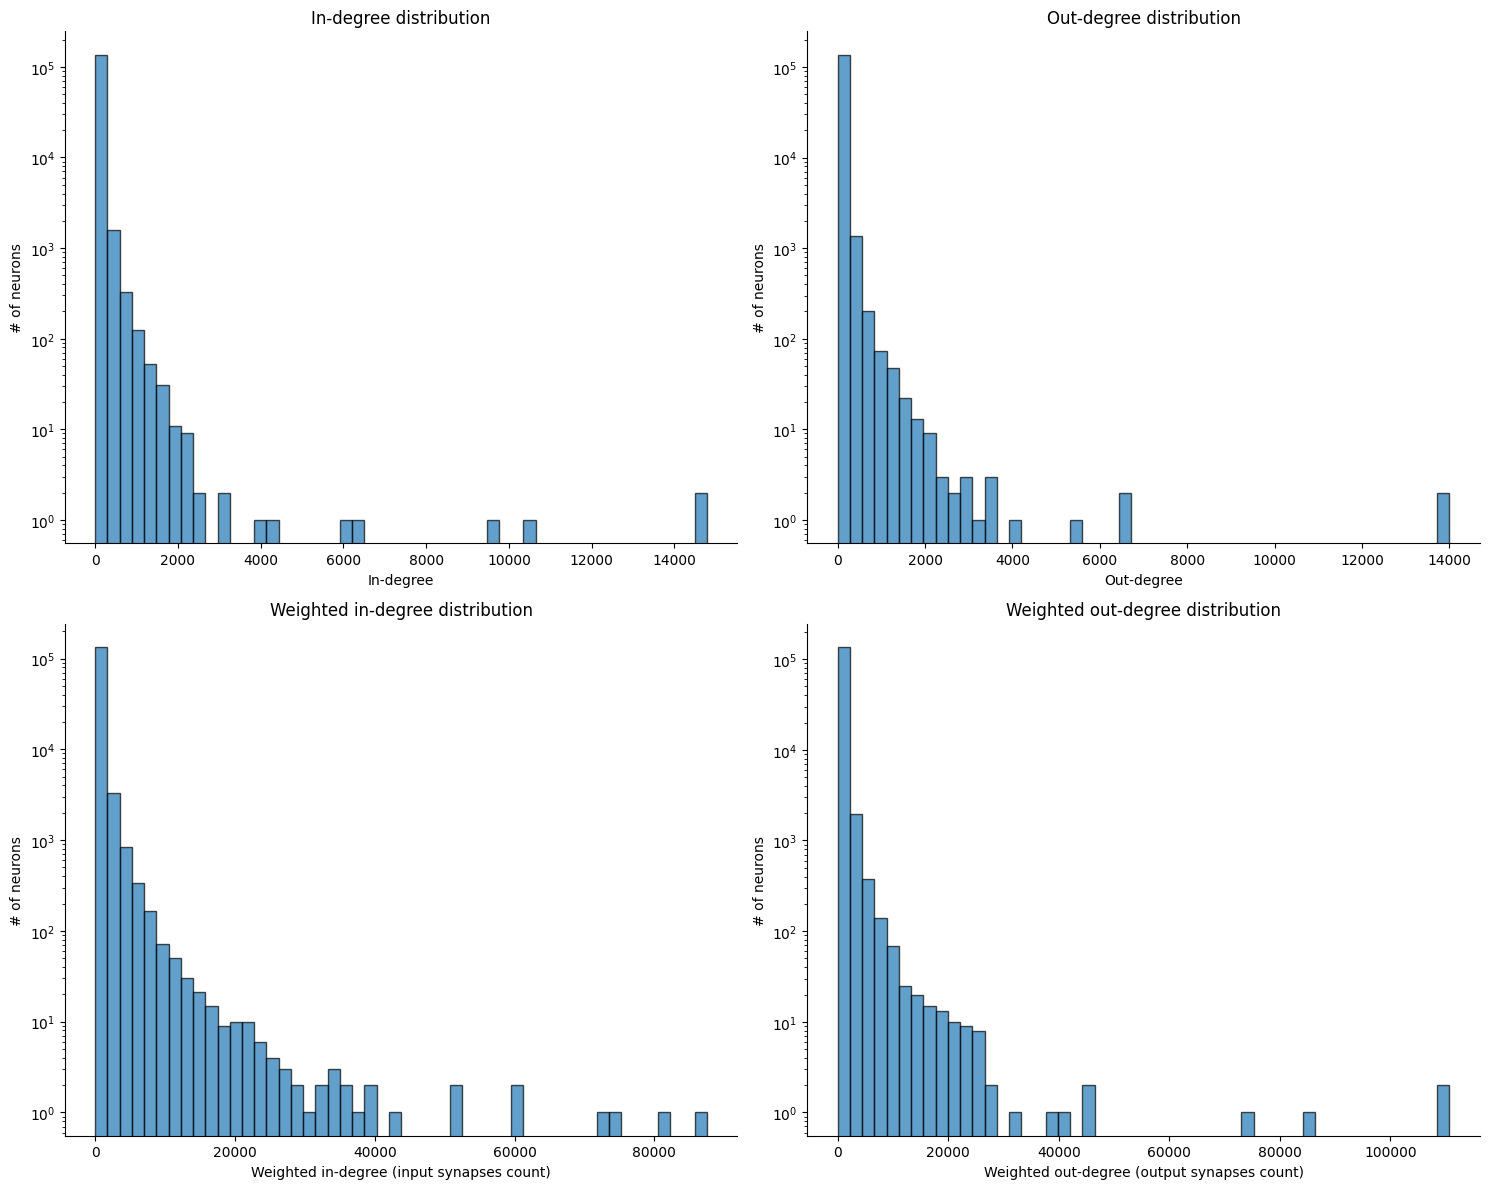

In [17]:
def _vis_degree_distributions() -> None:
    _, axes = plt.subplots(2, 2, figsize=(15, 12))

    # In-degree distribution
    axes[0, 0].hist(in_degrees, bins=50, alpha=0.7, edgecolor="black")
    axes[0, 0].set_title("In-degree distribution")
    axes[0, 0].set_xlabel("In-degree")
    axes[0, 0].set_ylabel("# of neurons")
    axes[0, 0].set_yscale("log")
    axes[0, 0].spines[["top", "right"]].set_visible(False)

    # Out-degree distribution
    axes[0, 1].hist(out_degrees, bins=50, alpha=0.7, edgecolor="black")
    axes[0, 1].set_title("Out-degree distribution")
    axes[0, 1].set_xlabel("Out-degree")
    axes[0, 1].set_ylabel("# of neurons")
    axes[0, 1].set_yscale("log")
    axes[0, 1].spines[["top", "right"]].set_visible(False)

    # Weighted in-degree distribution
    axes[1, 0].hist(weighted_in_degrees, bins=50, alpha=0.7, edgecolor="black")
    axes[1, 0].set_title("Weighted in-degree distribution")
    axes[1, 0].set_xlabel("Weighted in-degree (input synapses count)")
    axes[1, 0].set_ylabel("# of neurons")
    axes[1, 0].set_yscale("log")
    axes[1, 0].spines[["top", "right"]].set_visible(False)

    # Weighted out-degree distribution
    axes[1, 1].hist(weighted_out_degrees, bins=50, alpha=0.7, edgecolor="black")
    axes[1, 1].set_title("Weighted out-degree distribution")
    axes[1, 1].set_xlabel("Weighted out-degree (output synapses count)")
    axes[1, 1].set_ylabel("# of neurons")
    axes[1, 1].set_yscale("log")
    axes[1, 1].spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

_vis_degree_distributions()

And let's also visualize the relationship between neurons' in-degrees and out-degrees:

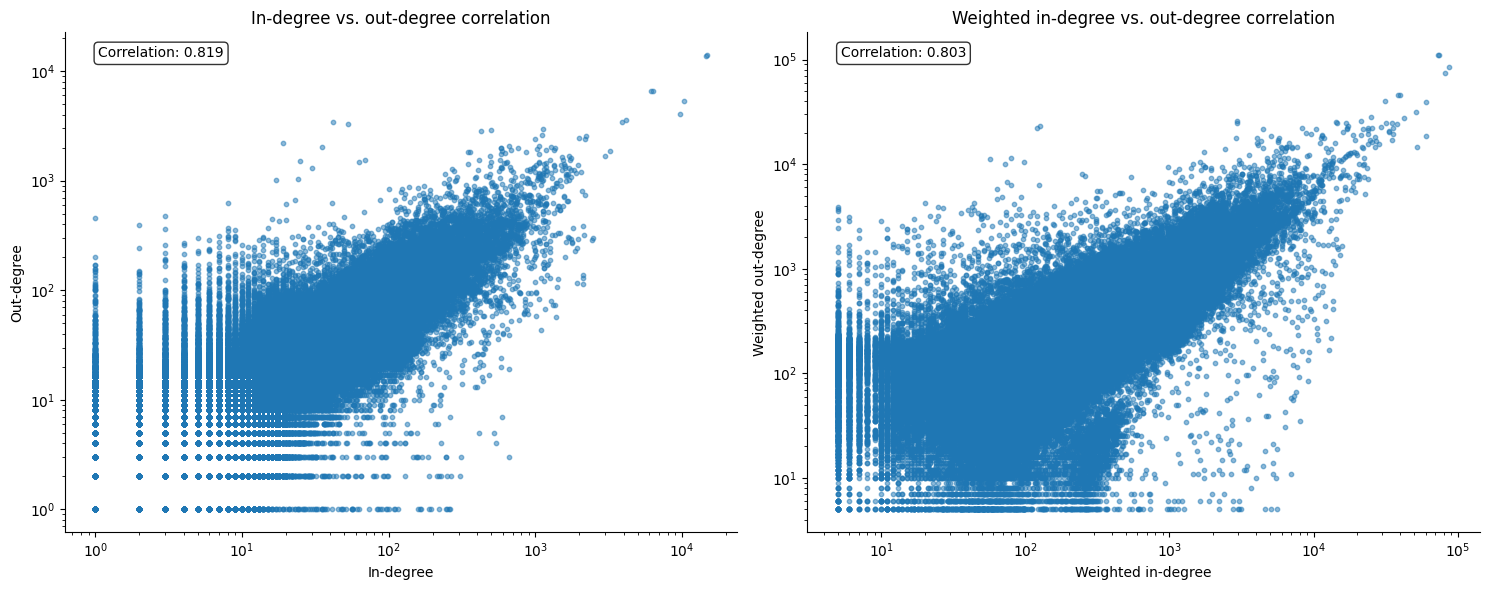

In [18]:
def _vis_degree_correlations() -> None:
    _, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Correlation between in-degree and out-degree
    axes[0].scatter(in_degrees, out_degrees, alpha=0.5, s=10)
    axes[0].set_title("In-degree vs. out-degree correlation")
    axes[0].set_xlabel("In-degree")
    axes[0].set_ylabel("Out-degree")
    axes[0].set_xscale("log")
    axes[0].set_yscale("log")
    axes[0].spines[["top", "right"]].set_visible(False)

    # Calculate correlation coefficient
    correlation_coef = np.corrcoef(in_degrees, out_degrees)[0, 1]
    axes[0].text(
        *(0.05, 0.95, f"Correlation: {correlation_coef:.3f}"), 
        transform=axes[0].transAxes,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    # Correlation between weighted in-degree and out-degree
    axes[1].scatter(weighted_in_degrees, weighted_out_degrees, alpha=0.5, s=10)
    axes[1].set_title("Weighted in-degree vs. out-degree correlation")
    axes[1].set_xlabel("Weighted in-degree")
    axes[1].set_ylabel("Weighted out-degree")
    axes[1].set_xscale("log")
    axes[1].set_yscale("log")
    axes[1].spines[["top", "right"]].set_visible(False)

    # Calculate weighted correlation coefficient
    weighted_correlation_coef = np.corrcoef(weighted_in_degrees, weighted_out_degrees)[0, 1]
    axes[1].text(
        *(0.05, 0.95, f"Correlation: {weighted_correlation_coef:.3f}"), 
        transform=axes[1].transAxes,
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

    plt.tight_layout()
    plt.show()

_vis_degree_correlations()

**Suggested exercise:** Select a neuron, then find all of the neurons that connect to it as inputs. Next, find all of the neurons that connect to those neurons as inputs, and so on, tracing back 3 or 4 hops from the cell you originally selected. Then make a point-and-dot visualization for each step in this tracing process in the style of the final figure generated in the _Visualizing group-level connectivity_ section.

In [19]:
### Your code here ###